# 🏥 Healthcare Dataset - Exploratory Data Analysis
**Notebook:** `data_exploration.ipynb`  
**Dataset:** `modified_healthcare_dataset.csv`  
**Objective:** Understand data structure, distributions, relationships, and quality issues before preprocessing.

---

## Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RAW_PATH = "healthcare_dataset.csv"
SEED = 42

## Load Data & Basic Inspection

In [4]:
df = pd.read_csv(RAW_PATH)

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

Shape : 55,500 rows × 16 columns
Memory: 47.01 MB


In [5]:
# First look at the raw values
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,19,Female,AB+,Infections,2024-01-31,Matthew Smith,Northwestern Memorial Hospital,Blue Cross,2212.272701,328,Emergency,2024-02-07,Azithromycin,Normal,7
1,Leslie Terry,15,Female,B-,Flu,2019-08-20,Samantha Davies,UI Health (University of Illinois Hospital),UnitedHealthcare,3185.161388,265,Emergency,2019-08-22,Tamiflu,Abnormal,2
2,Danny Smith,50,Female,A+,Cancer,2022-09-22,Tiffany Mitchell,UI Health (University of Illinois Hospital),Blue Cross,72055.214065,205,Elective,2022-10-30,Cisplatin,Inconclusive,38
3,Andrew Watts,24,Female,O+,Asthma,2020-11-18,Kevin Wells,UI Health (University of Illinois Hospital),Aetna,4092.601229,450,Elective,2020-11-19,Prednisone,Normal,1
4,Adrienne Bell,80,Female,A+,Heart Disease,2022-09-19,Kathleen Hanna,Northwestern Memorial Hospital,Cigna,47985.660254,458,Routine,2022-10-27,Beta-blockers,Inconclusive,38


In [9]:
import pandas as pd

summary = pd.DataFrame({
    "Attribute": df.columns,
    "Data Type": df.dtypes.astype(str)
})

summary

,Attribute,Data Type
Name,Name,str
Age,Age,int64
Gender,Gender,str
Blood Type,Blood Type,str
Medical Condition,Medical Condition,str
Date of Admission,Date of Admission,str
Doctor,Doctor,str
Hospital,Hospital,str
Insurance Provider,Insurance Provider,str
Billing Amount,Billing Amount,float64


In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

# Create summary
summary = pd.DataFrame({
    "Attribute": df.columns,
    "Data Type": df.dtypes.astype(str)
})

# Map better data types
def map_dtype(dtype):
    if "int" in dtype:
        return "Integer"
    elif "float" in dtype:
        return "Float"
    else:
        return "str"

summary["Data Type"] = summary["Data Type"].apply(map_dtype)

# Descriptions (MATCH YOUR COLUMN NAMES EXACTLY)
descriptions = {
    "Name": "Patient name",
    "Age": "Patient age in years (0–120)",
    "Gender": "Male / Female",
    "Blood Type": "A+, A-, B+, B-, AB+, AB-, O+, O-",
    "Medical Condition": "Primary diagnosis",
    "Date of Admission": "Admission date",
    "Doctor": "Doctor name",
    "Hospital": "Hospital name",
    "Insurance Provider": "Insurance company",
    "Billing Amount": "Total bill in USD",
    "Room Number": "Room number",
    "Admission Type": "Elective / Urgent / Emergency",
    "Discharge Date": "Discharge date",
    "Medication": "Prescribed medication",
    "Test Results": "Normal / Inconclusive / Abnormal",
    "Length of Stay": "Days stayed in hospital"
}

summary["Description"] = summary["Attribute"].map(descriptions)

# SHOW TABLE
summary

,Attribute,Data Type,Description
Name,Name,str,Patient name
Age,Age,Integer,Patient age in years (0–120)
Gender,Gender,str,Male / Female
Blood Type,Blood Type,str,"A+, A-, B+, B-, AB+, AB-, O+, O-"
Medical Condition,Medical Condition,str,Primary diagnosis
Date of Admission,Date of Admission,str,Admission date
Doctor,Doctor,str,Doctor name
Hospital,Hospital,str,Hospital name
Insurance Provider,Insurance Provider,str,Insurance company
Billing Amount,Billing Amount,Float,Total bill in USD


In [86]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
 15  Length of Stay      55500 non-null  int64  
dtypes: f

In [87]:
# Statistical summary - numerical columns
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
Age,55500.000000,48.001622,21.105827,5.000000,32.000000,50.000000,65.000000,90.000000
Billing Amount,55500.000000,21835.044635,23574.413594,500.220989,4195.525741,11089.537763,35887.703406,99997.797977
Room Number,55500.000000,301.134829,115.243069,101.000000,202.000000,302.000000,401.000000,500.000000
Length of Stay,55500.000000,17.841009,20.272294,1.000000,4.000000,8.000000,28.000000,89.000000


In [88]:
# Statistical summary - categorical columns
df.describe(include="object").T

,count,unique,top,freq
Name,55500,40235,Michael Williams,24
Gender,55500,2,Female,27955
Blood Type,55500,8,O+,15696
Medical Condition,55500,8,Flu,7046
Date of Admission,55500,1827,2024-03-16,50
Doctor,55500,40341,Michael Smith,27
Hospital,55500,4,Northwestern Memorial Hospital,14070
Insurance Provider,55500,5,Cigna,11183
Admission Type,55500,4,Emergency,20104
Discharge Date,55500,1901,2022-02-04,53


Summary statistics

In [89]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,40235,Michael Williams,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,48.001622,21.105827,5.0,32.0,50.0,65.0,90.0
Gender,55500,2,Female,27955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,O+,15696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,8,Flu,7046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,4,Northwestern Memorial Hospital,14070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,21835.044635,23574.413594,500.220989,4195.525741,11089.537763,35887.703406,99997.797977


## Missing Values & Duplicates

In [90]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [91]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## Univariate Analysis


### Numerical Columns

In [92]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print("Numerical columns:", num_cols)

Numerical columns: ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']


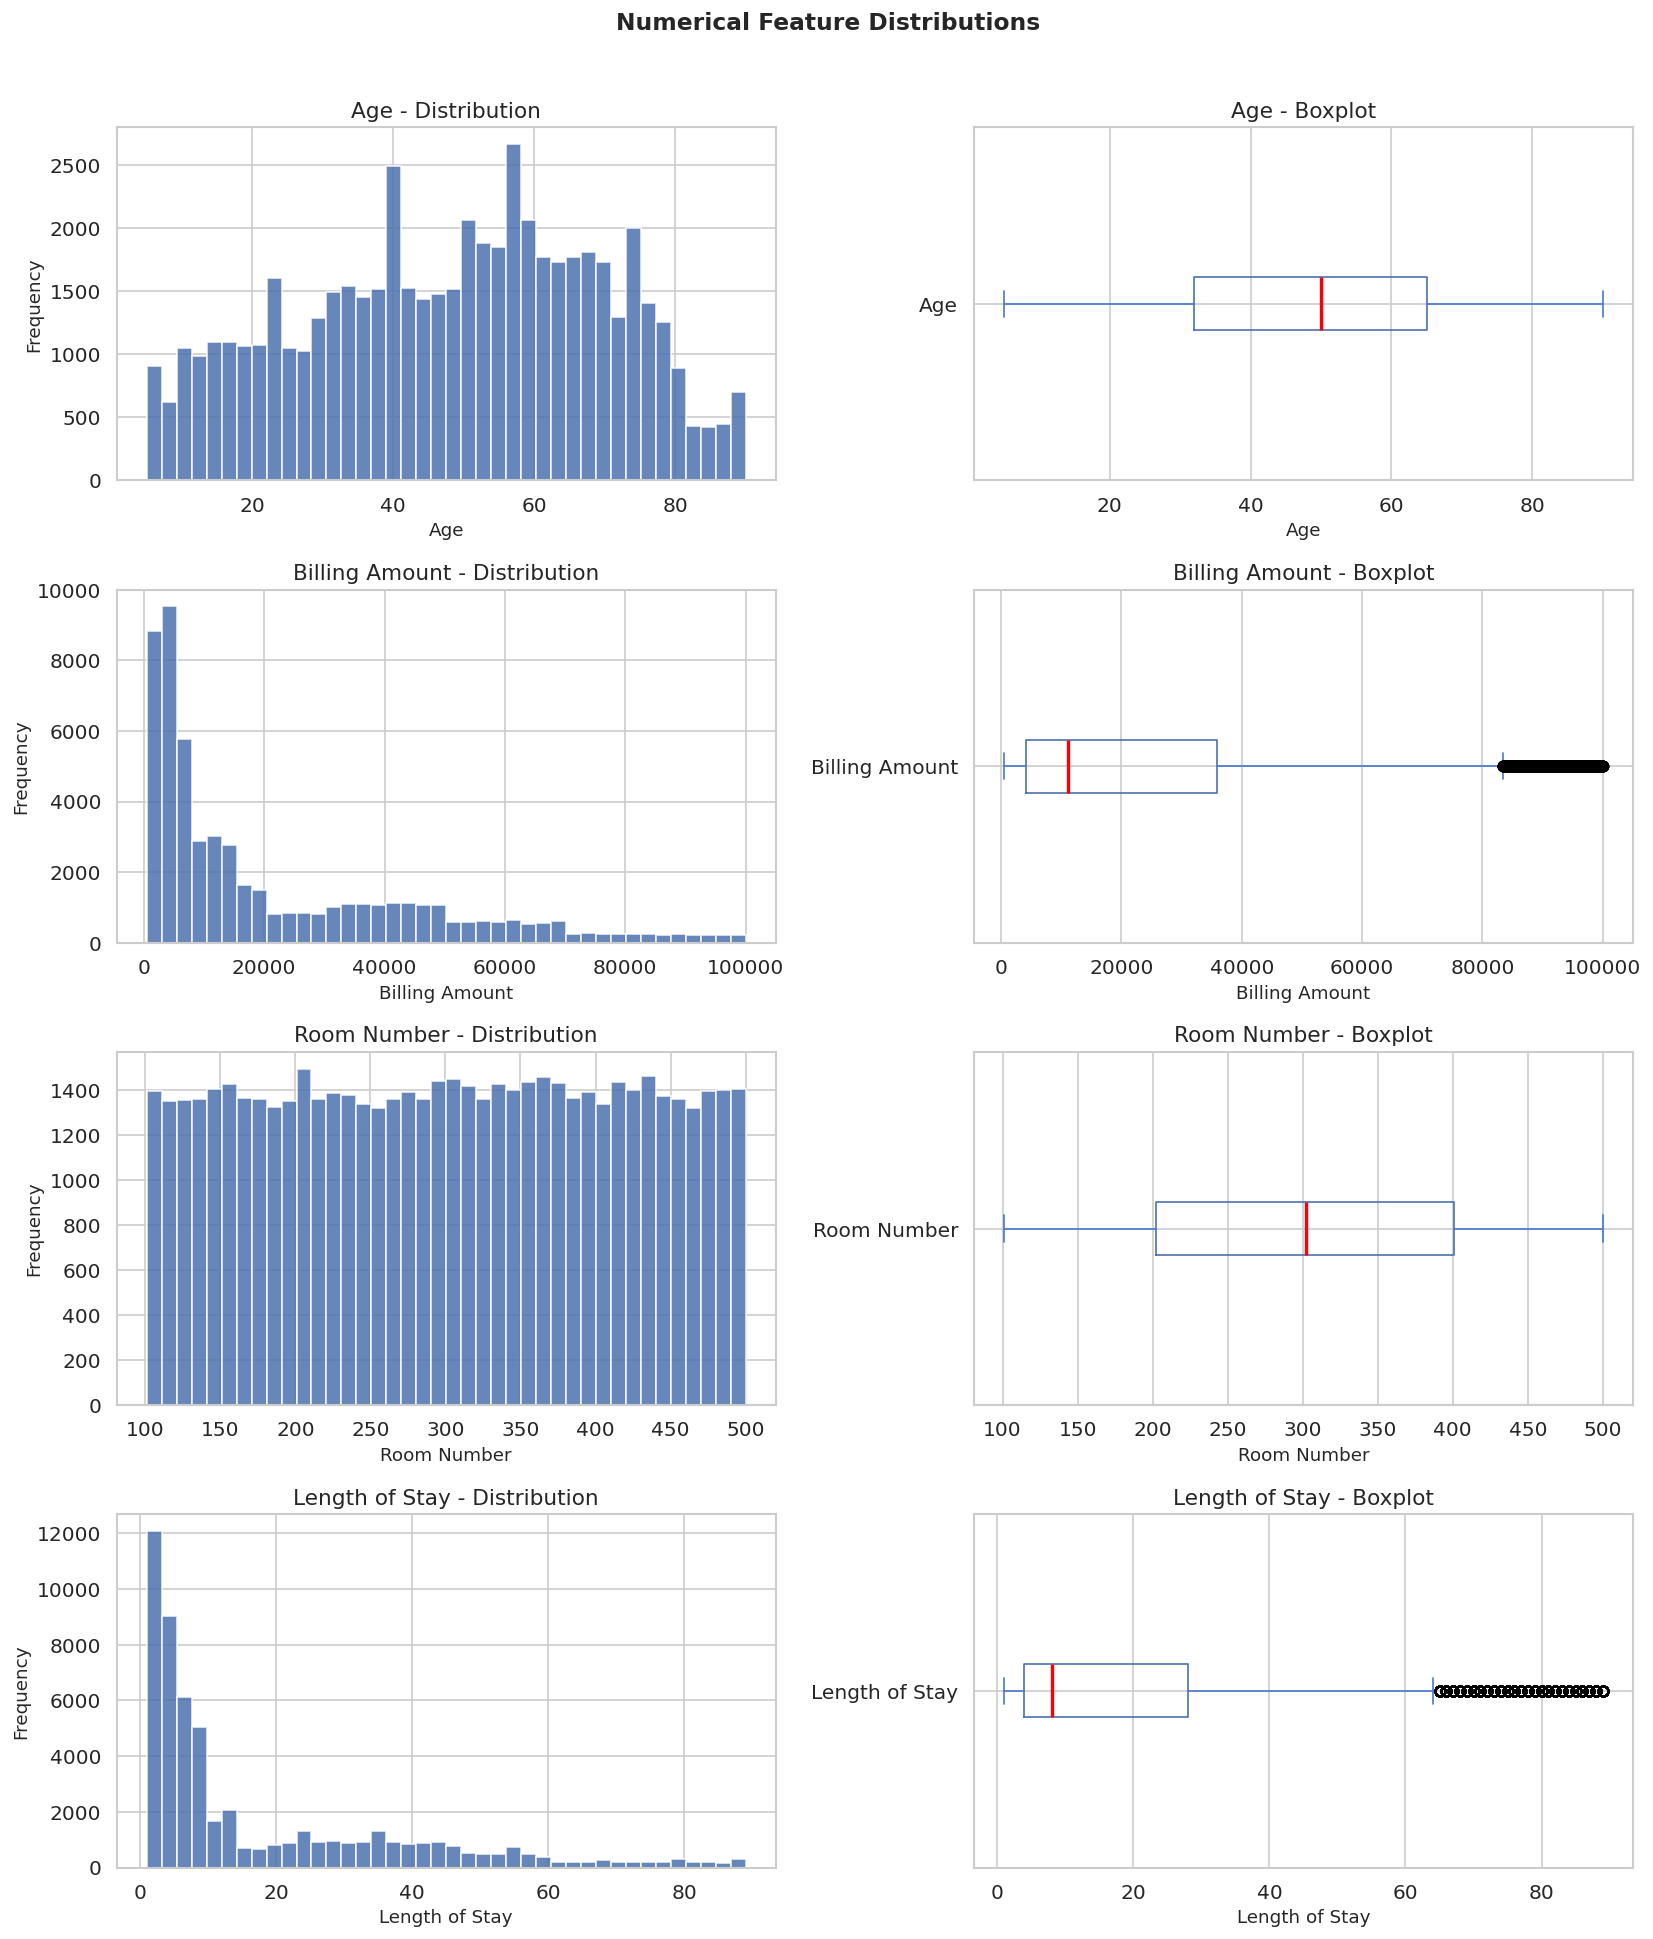

In [93]:
# Distribution plots for every numerical column
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
axes = axes if n > 1 else [axes]

for i, col in enumerate(num_cols):
    series = df[col].dropna()

    # Histogram + KDE
    axes[i][0].set_title(f"{col} - Distribution")
    series.plot.hist(bins=40, ax=axes[i][0], color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i][0].set_xlabel(col)

    # Boxplot (outlier view)
    axes[i][1].set_title(f"{col} - Boxplot")
    series.plot.box(ax=axes[i][1], vert=False,
                    boxprops=dict(color="#4C72B0"),
                    medianprops=dict(color="red", linewidth=2))
    axes[i][1].set_xlabel(col)

plt.suptitle("Numerical Feature Distributions", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

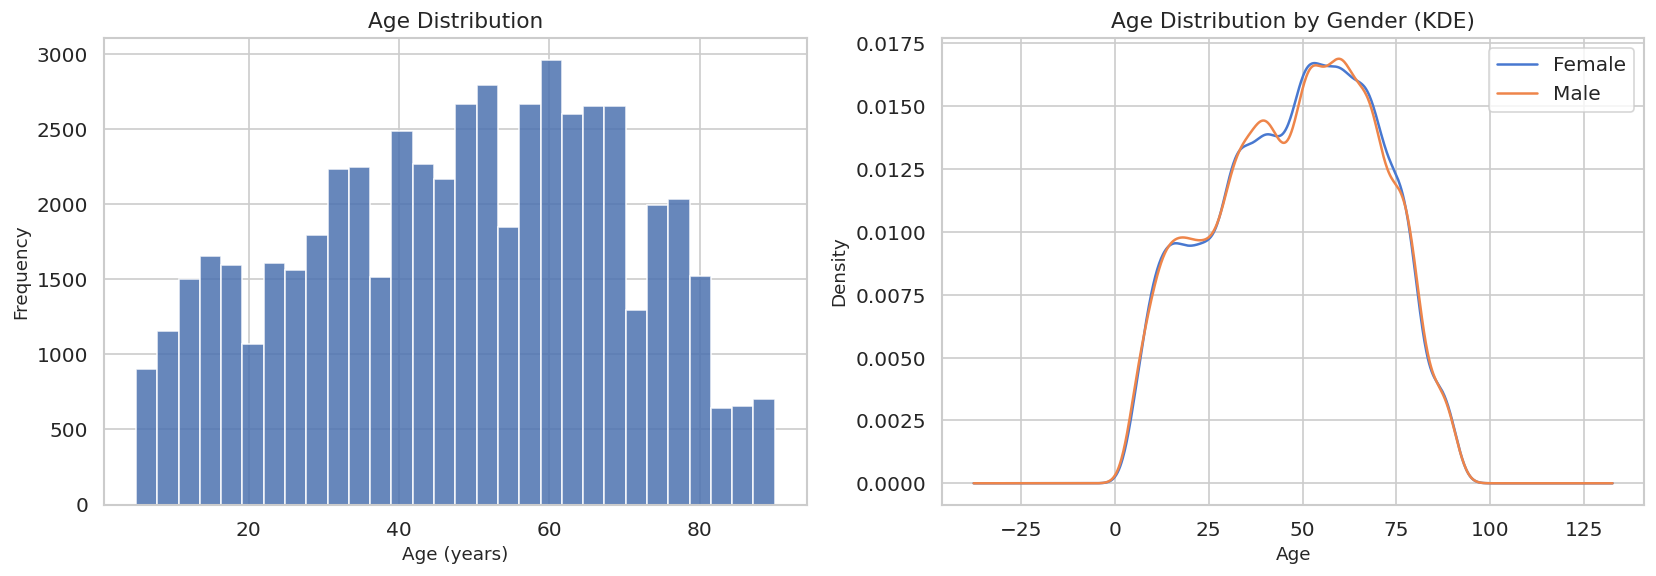

In [94]:
# Age-specific analysis (key demographic)
if "Age" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Age distribution by decade
    df["Age"].plot.hist(bins=30, ax=axes[0], color="#4C72B0",
                        edgecolor="white", alpha=0.85)
    axes[0].set_title("Age Distribution")
    axes[0].set_xlabel("Age (years)")

    # Age by gender
    if "Gender" in df.columns:
        for gender, grp in df.groupby("Gender")["Age"]:
            grp.plot.kde(ax=axes[1], label=gender)
        axes[1].set_title("Age Distribution by Gender (KDE)")
        axes[1].set_xlabel("Age")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

### Categorical Columns

In [95]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

# Cardinality overview
card = pd.DataFrame({
    "unique_values": [df[c].nunique() for c in cat_cols],
    "top_value":     [df[c].mode()[0] if df[c].notna().any() else "N/A" for c in cat_cols],
    "top_freq_pct":  [(df[c].value_counts(normalize=True).iloc[0] * 100).round(1) for c in cat_cols]
}, index=cat_cols)
display(card)


Categorical columns: ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


,unique_values,top_value,top_freq_pct
Name,40235,Michael Williams,0.0
Gender,2,Female,50.4
Blood Type,8,O+,28.3
Medical Condition,8,Flu,12.7
Date of Admission,1827,2024-03-16,0.1
Doctor,40341,Michael Smith,0.0
Hospital,4,Northwestern Memorial Hospital,25.4
Insurance Provider,5,Cigna,20.1
Admission Type,4,Emergency,36.2
Discharge Date,1901,2022-02-04,0.1


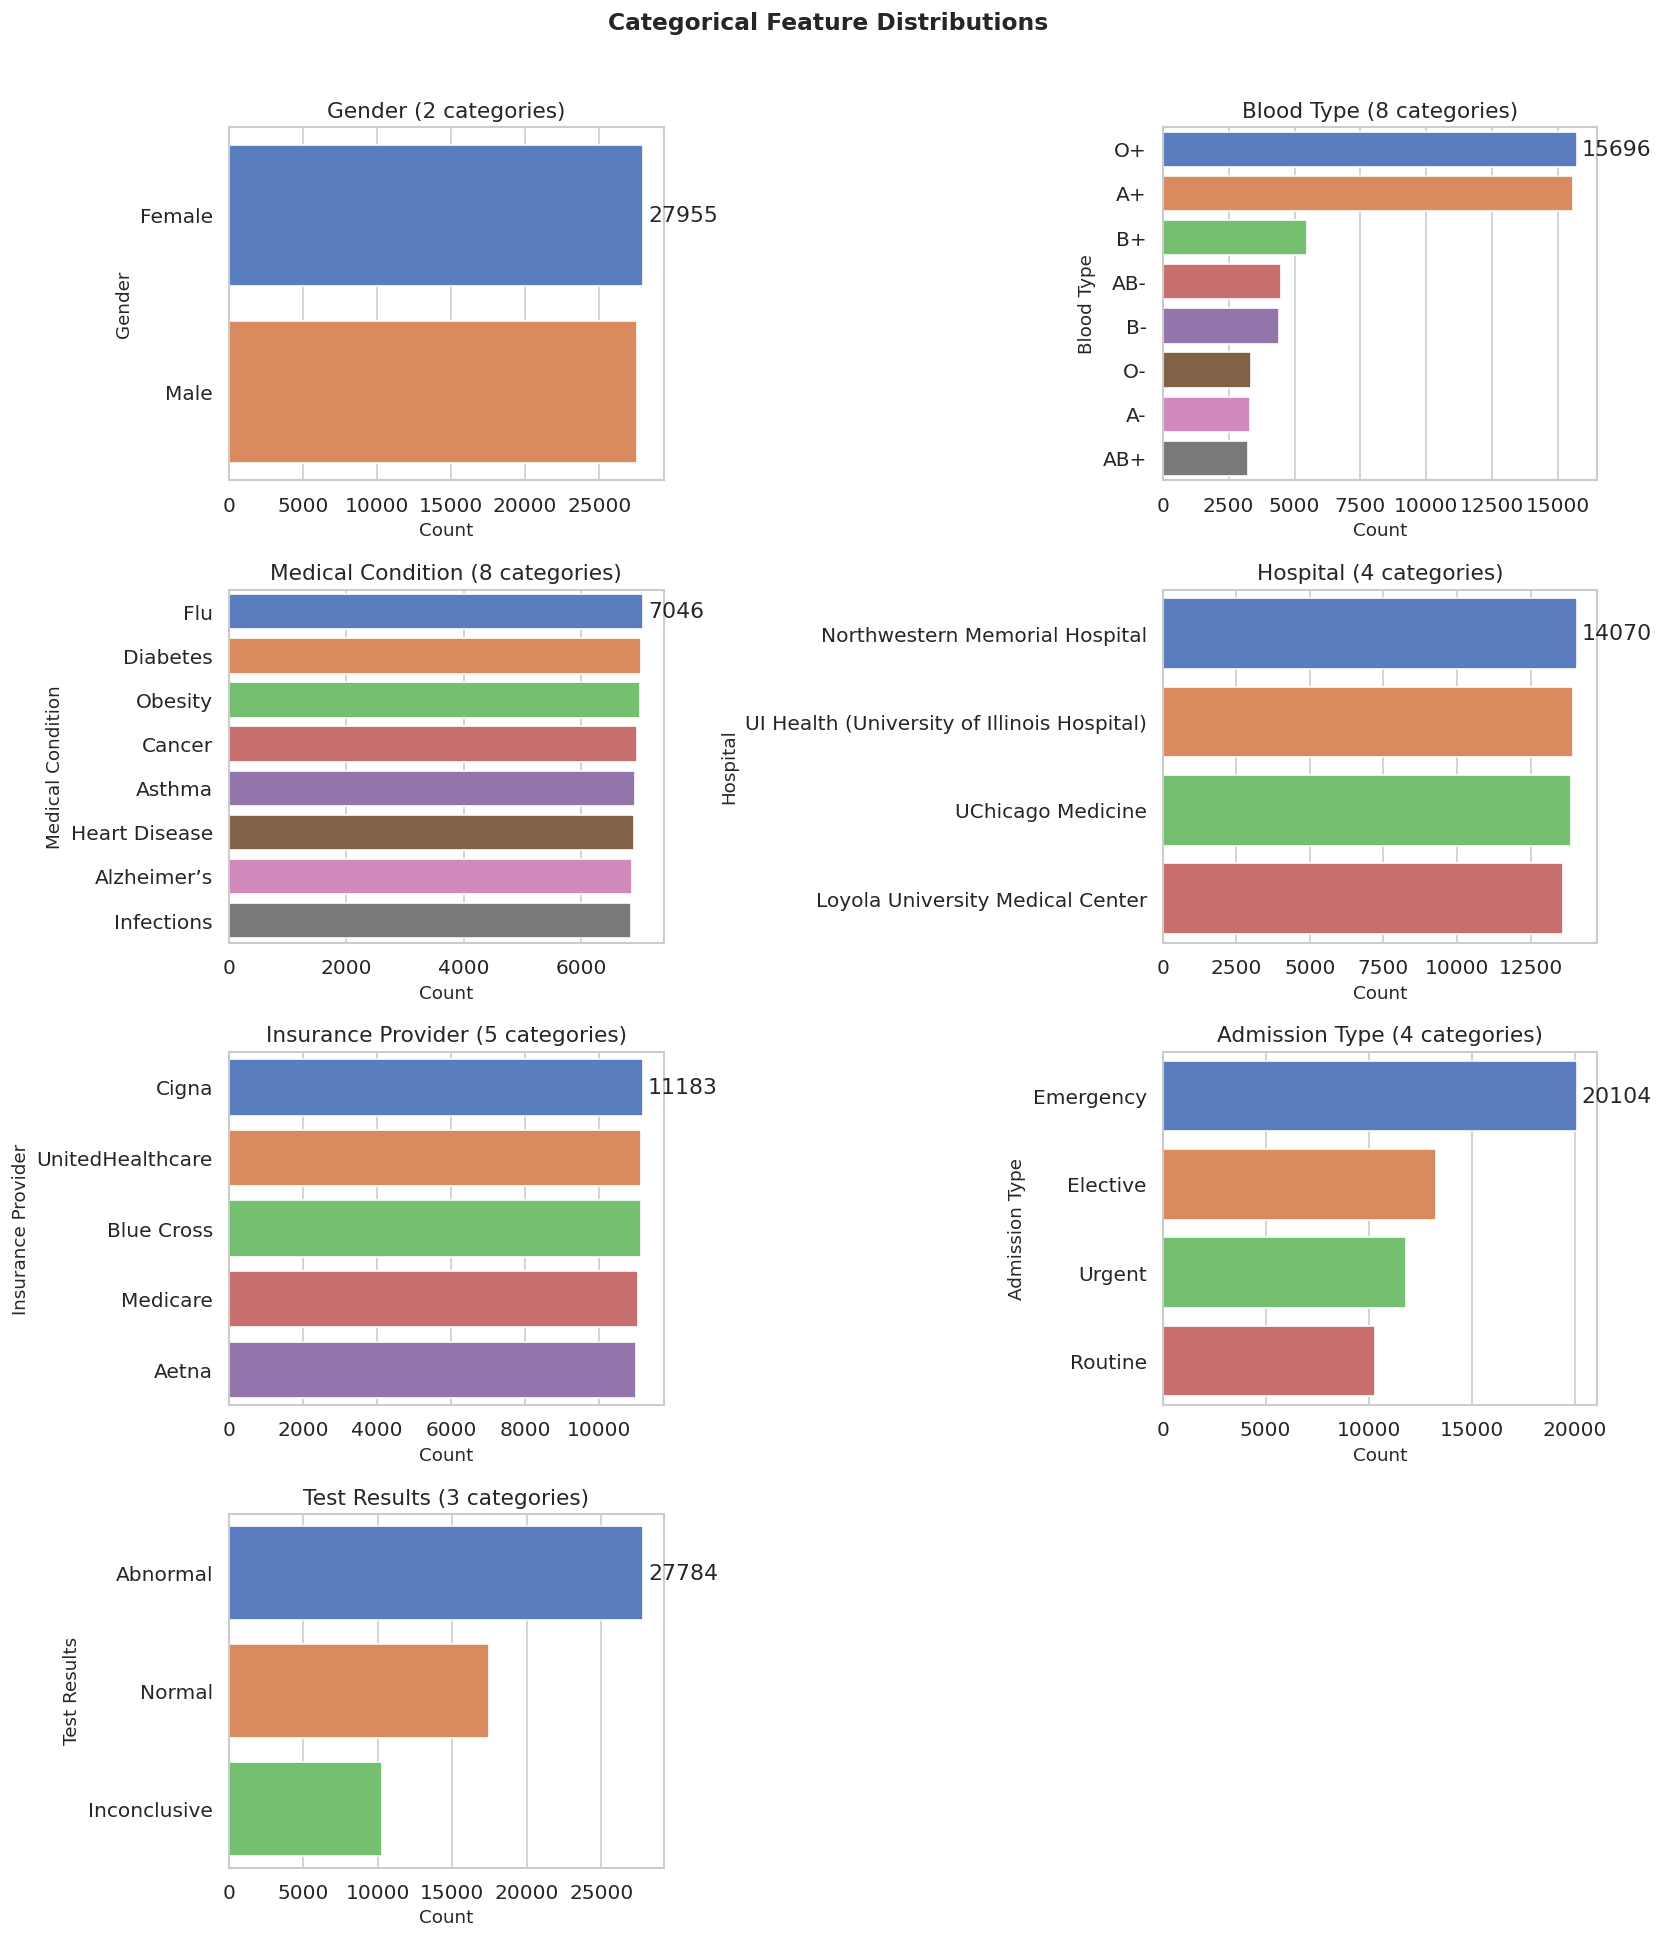

In [96]:
# Bar charts for low-cardinality categorical columns
low_card = [c for c in cat_cols if df[c].nunique() <= 20]

n = len(low_card)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(low_card):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i],
                palette="muted", orient="h")
    axes[i].set_title(f"{col} ({df[col].nunique()} categories)")
    axes[i].set_xlabel("Count")
    axes[i].bar_label(axes[i].containers[0], fmt="%d", padding=3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Distributions", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Bivariate & Multivariate Analysis

### Correlation Matrix

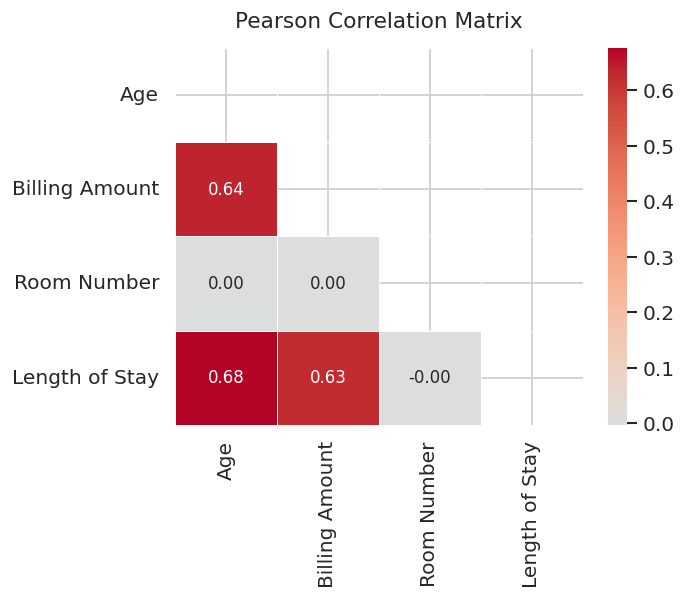

In [97]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(max(6, len(num_cols) * 1.5),
                                    max(5, len(num_cols) * 1.3)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, ax=ax,
                annot_kws={"size": 10})
    ax.set_title("Pearson Correlation Matrix", pad=12)
    plt.tight_layout()
    plt.show()

### Medical Condition vs. Age & Billing Amount

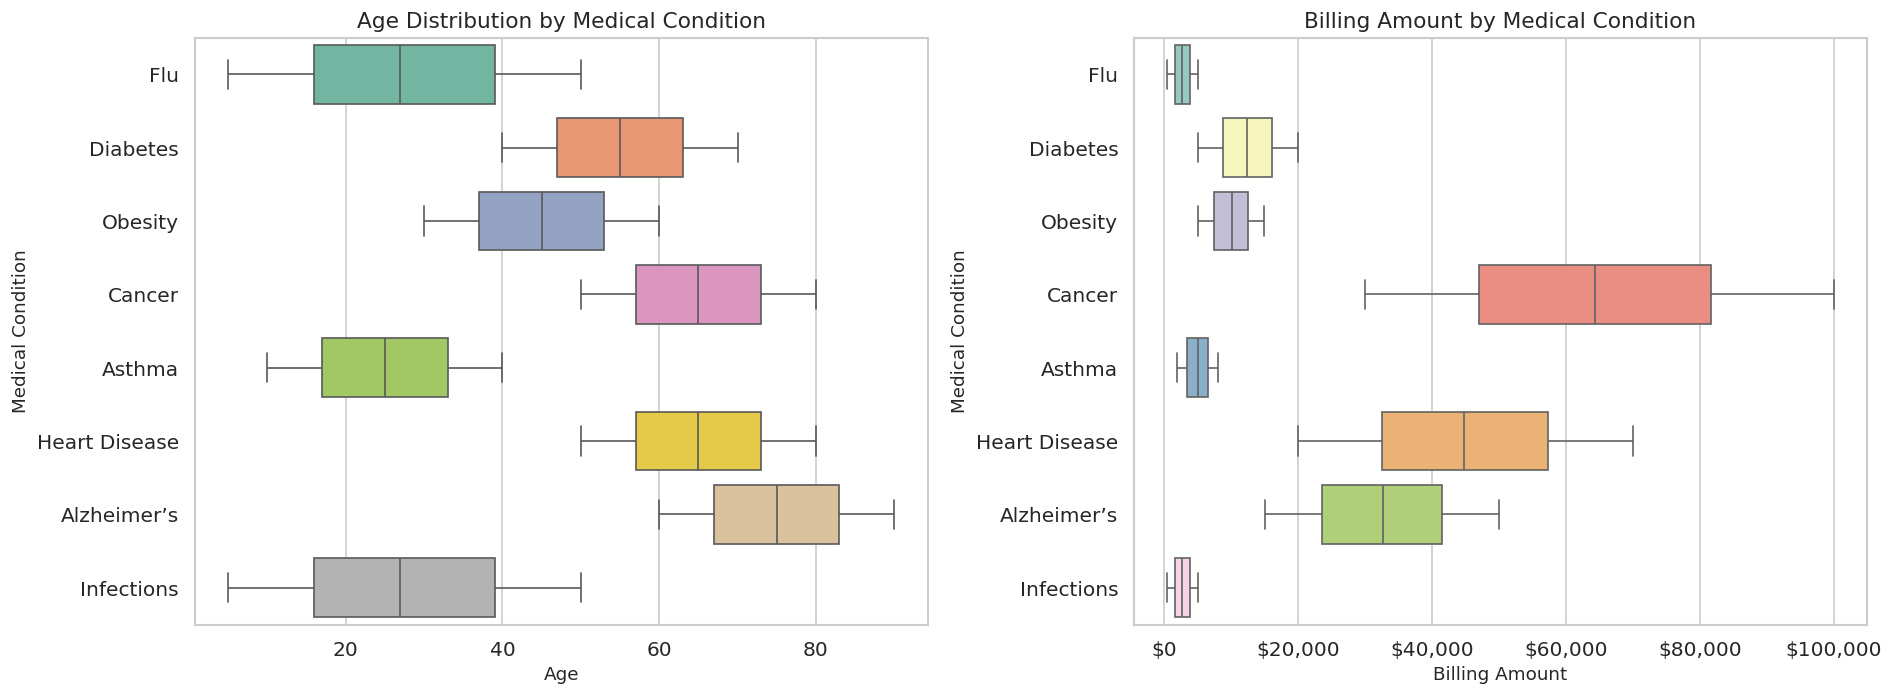

In [98]:
if "Medical Condition" in df.columns and "Age" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Age distribution per condition
    order = df["Medical Condition"].value_counts().index
    sns.boxplot(data=df, y="Medical Condition", x="Age",
                order=order, palette="Set2", orient="h", ax=axes[0])
    axes[0].set_title("Age Distribution by Medical Condition")

    # Billing per condition
    if "Billing Amount" in df.columns:
        sns.boxplot(data=df, y="Medical Condition", x="Billing Amount",
                    order=order, palette="Set3", orient="h", ax=axes[1])
        axes[1].set_title("Billing Amount by Medical Condition")
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"${x:,.0f}"))

    plt.tight_layout()
    plt.show()

### Admission Type Analysis

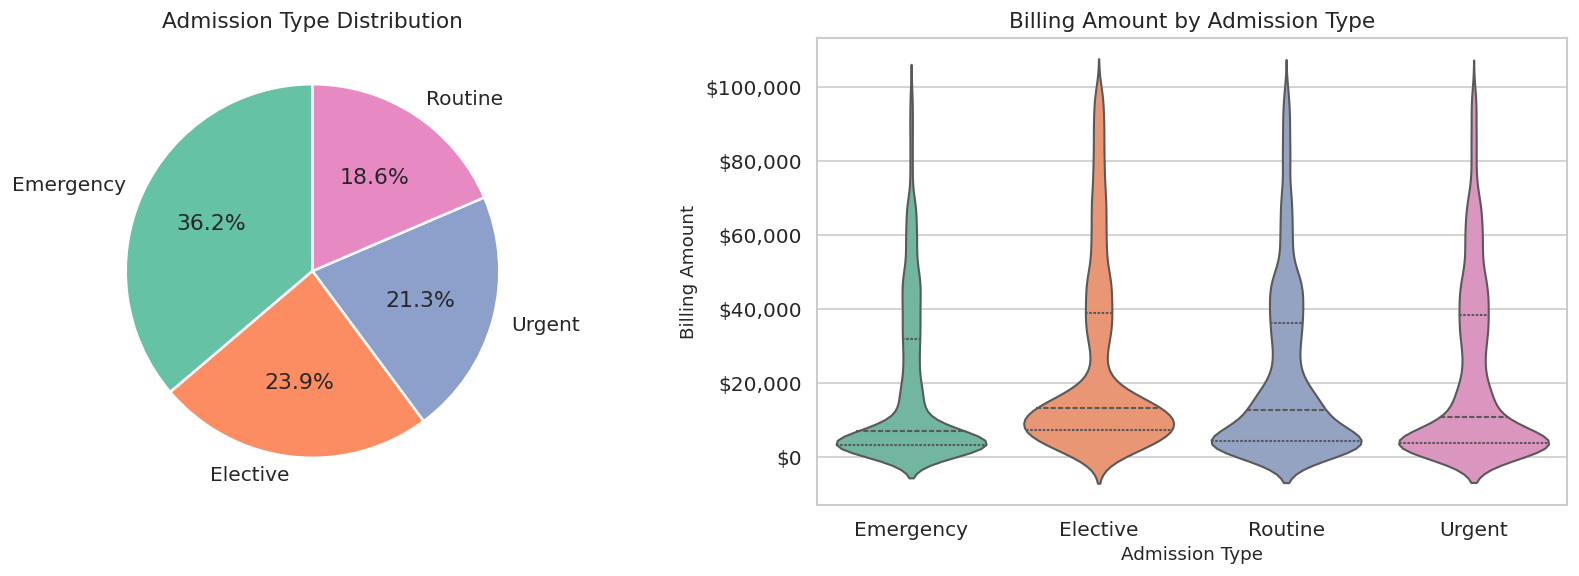

In [99]:
if "Admission Type" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count of each admission type
    counts = df["Admission Type"].value_counts()
    axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
                colors=sns.color_palette("Set2"), startangle=90,
                wedgeprops=dict(edgecolor="white", linewidth=1.5))
    axes[0].set_title("Admission Type Distribution")

    # Billing by admission type
    if "Billing Amount" in df.columns:
        sns.violinplot(data=df, x="Admission Type", y="Billing Amount",
                       palette="Set2", ax=axes[1], inner="quartile")
        axes[1].set_title("Billing Amount by Admission Type")
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"${y:,.0f}"))

    plt.tight_layout()
    plt.show()

### Test Results Analysis

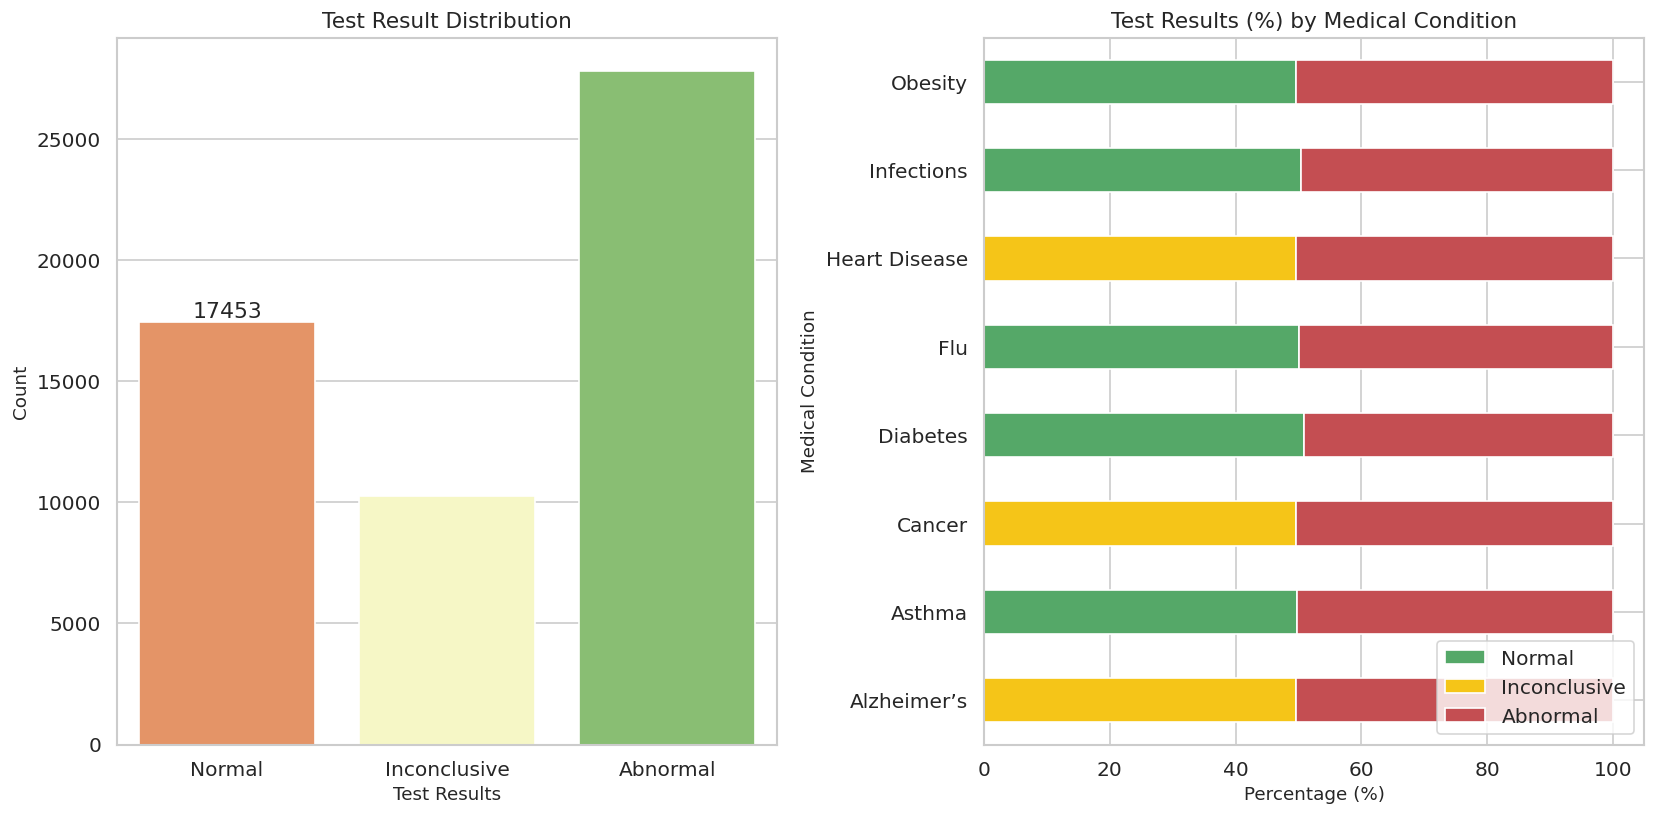

In [100]:
if "Test Results" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Overall test result distribution
    counts = df["Test Results"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette="RdYlGn",
                ax=axes[0], order=["Normal", "Inconclusive", "Abnormal"])
    axes[0].set_title("Test Result Distribution")
    axes[0].set_ylabel("Count")
    axes[0].bar_label(axes[0].containers[0], fmt="%d")

    # Test results vs. medical condition
    if "Medical Condition" in df.columns:
        ct = pd.crosstab(df["Medical Condition"], df["Test Results"], normalize="index") * 100
        ct[["Normal", "Inconclusive", "Abnormal"]].plot.barh(
            stacked=True, ax=axes[1],
            color={"Normal": "#55a868", "Inconclusive": "#f5c518", "Abnormal": "#c44e52"})
        axes[1].set_title("Test Results (%) by Medical Condition")
        axes[1].set_xlabel("Percentage (%)")
        axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

### Hospital Stay Duration Analysis

In [101]:
hs_df = df.copy()

In [102]:
hs_df["date_of_admission"] = pd.to_datetime(hs_df["Date of Admission"], errors="coerce")
hs_df["discharge_date"] = pd.to_datetime(hs_df["Discharge Date"], errors="coerce")
hs_df["length_of_stay"] = (hs_df["discharge_date"] - hs_df["date_of_admission"]).dt.days
hs_df = hs_df[hs_df["length_of_stay"].between(0, 365)]

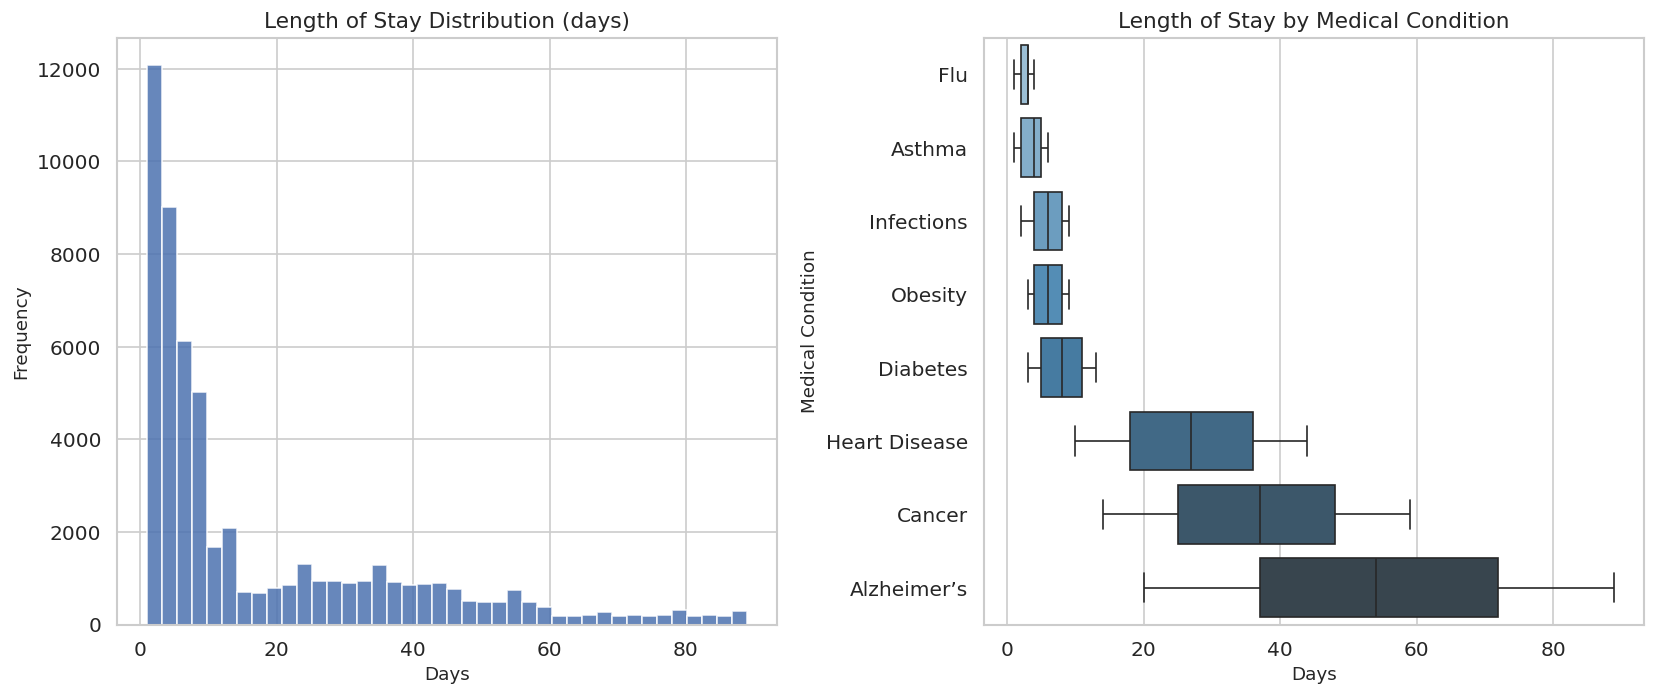

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hs_df["length_of_stay"].plot.hist(bins=40, ax=axes[0], color="#4C72B0",
                                    edgecolor="white", alpha=0.85)
axes[0].set_title("Length of Stay Distribution (days)")
axes[0].set_xlabel("Days")

if "Medical Condition" in hs_df.columns:
  order = hs_df.groupby("Medical Condition")["length_of_stay"].median().sort_values().index
  sns.boxplot(data=hs_df, y="Medical Condition", x="length_of_stay",
              order=order, palette="Blues_d", orient="h", ax=axes[1])
  axes[1].set_title("Length of Stay by Medical Condition")
  axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

In [104]:
print(hs_df["length_of_stay"].describe().to_string())

count    55500.000000
mean        17.841009
std         20.272294
min          1.000000
25%          4.000000
50%          8.000000
75%         28.000000
max         89.000000


### Temporal Trends

In [105]:
tt_df = df.copy()

In [106]:
tt_df["date_of_admission"] = pd.to_datetime(tt_df["Date of Admission"], errors="coerce")
tt_df['year_month'] = tt_df['date_of_admission'].dt.to_period('M')

In [107]:
monthly = tt_df.groupby("year_month").size().reset_index(name="admissions")
monthly["year_month_str"] = monthly["year_month"].astype(str)

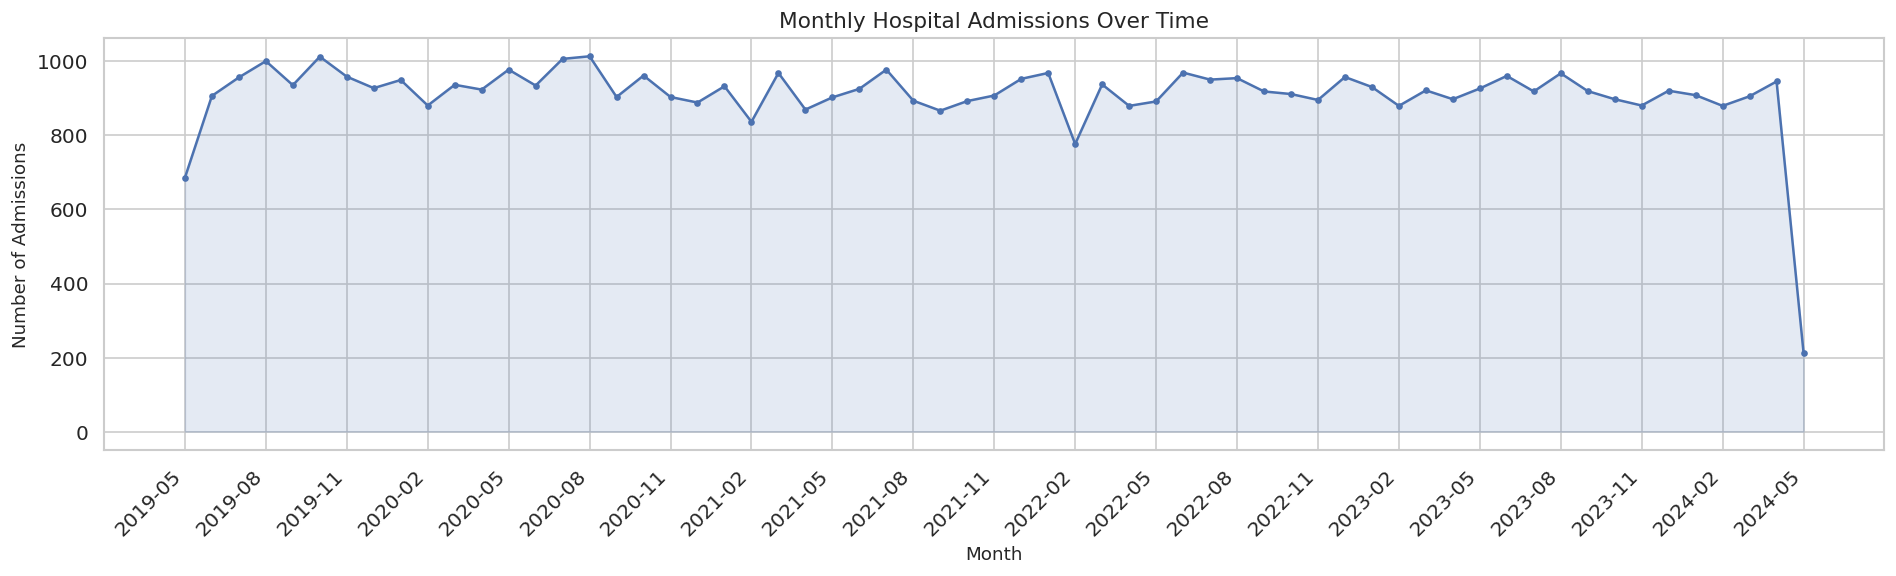

In [108]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly["year_month_str"], monthly["admissions"],
        color="#4C72B0", linewidth=1.5, marker="o", markersize=3)
ax.fill_between(monthly["year_month_str"], monthly["admissions"],
                alpha=0.15, color="#4C72B0")
ax.set_title("Monthly Hospital Admissions Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Admissions")

# Rotate x-labels cleanly
step = max(1, len(monthly) // 20)
ticks = range(0, len(monthly), step)
ax.set_xticks([monthly["year_month_str"].iloc[i] for i in ticks])
ax.set_xticklabels([monthly["year_month_str"].iloc[i] for i in ticks],
                   rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insurance Provider & Hospital

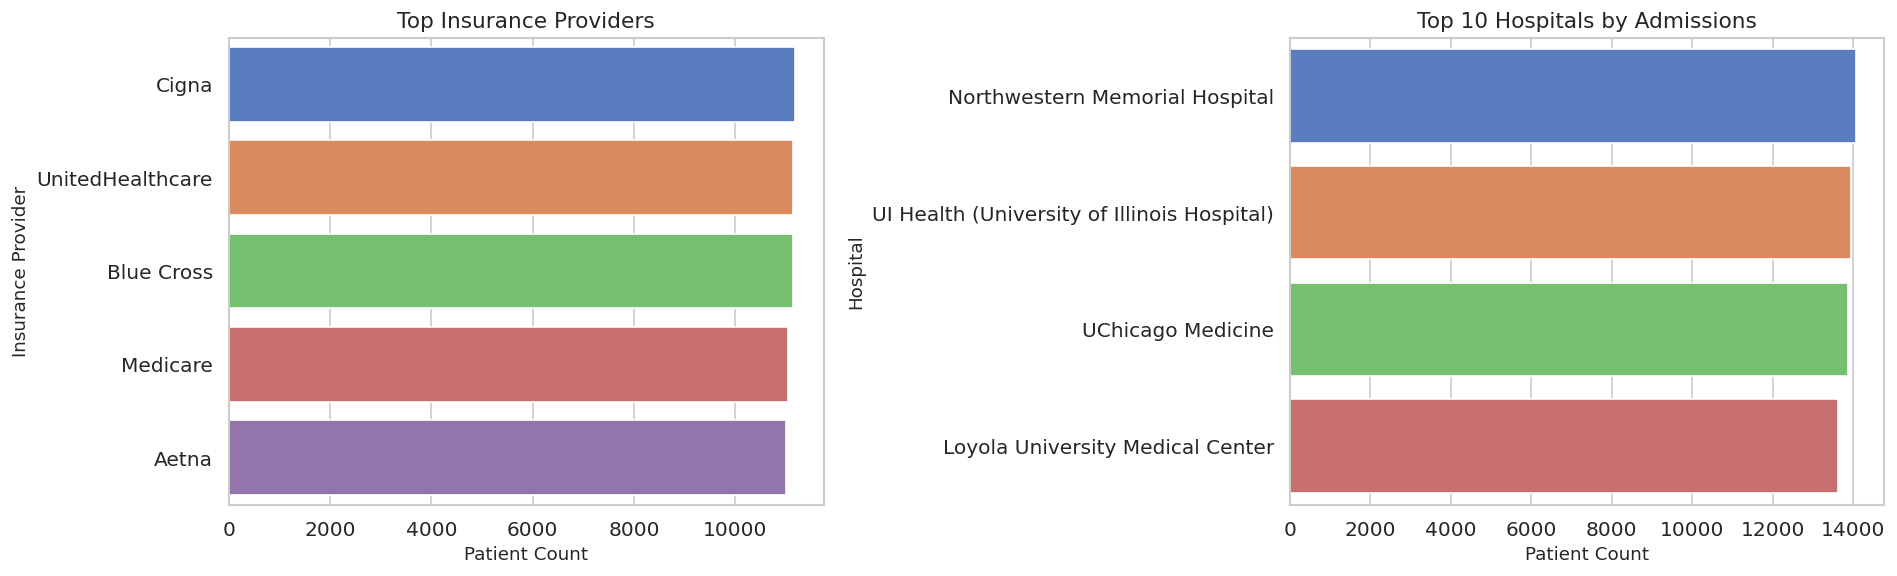

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if "Insurance Provider" in df.columns:
    ins = df["Insurance Provider"].value_counts().head(10)
    sns.barplot(x=ins.values, y=ins.index, ax=axes[0], palette="muted")
    axes[0].set_title("Top Insurance Providers")
    axes[0].set_xlabel("Patient Count")

if "Hospital" in df.columns:
    hosp = df["Hospital"].value_counts().head(10)
    sns.barplot(x=hosp.values, y=hosp.index, ax=axes[1], palette="muted")
    axes[1].set_title("Top 10 Hospitals by Admissions")
    axes[1].set_xlabel("Patient Count")

plt.tight_layout()
plt.show()

## Dataset Overview
* The dataset contains a total of 55,500 records and 16 columns.
* There are no duplicate rows, ensuring data uniqueness.
* All columns are complete with no missing (null) values.
* The age of patients ranges from 5 to 90 years, representing a wide * demographic.
* Billing amounts range from 500.22 to 99,997.80 dollers($) indicating significant cost variation.
* The dataset includes 8 unique medical conditions.
* The gender distribution consists of two categories: Female and Male.
* The test results are categorized into three types: Normal, Abnormal and Inconclusive.